<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN-WK-9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Simulating Progressive Growth from 8x8 to 64x64...


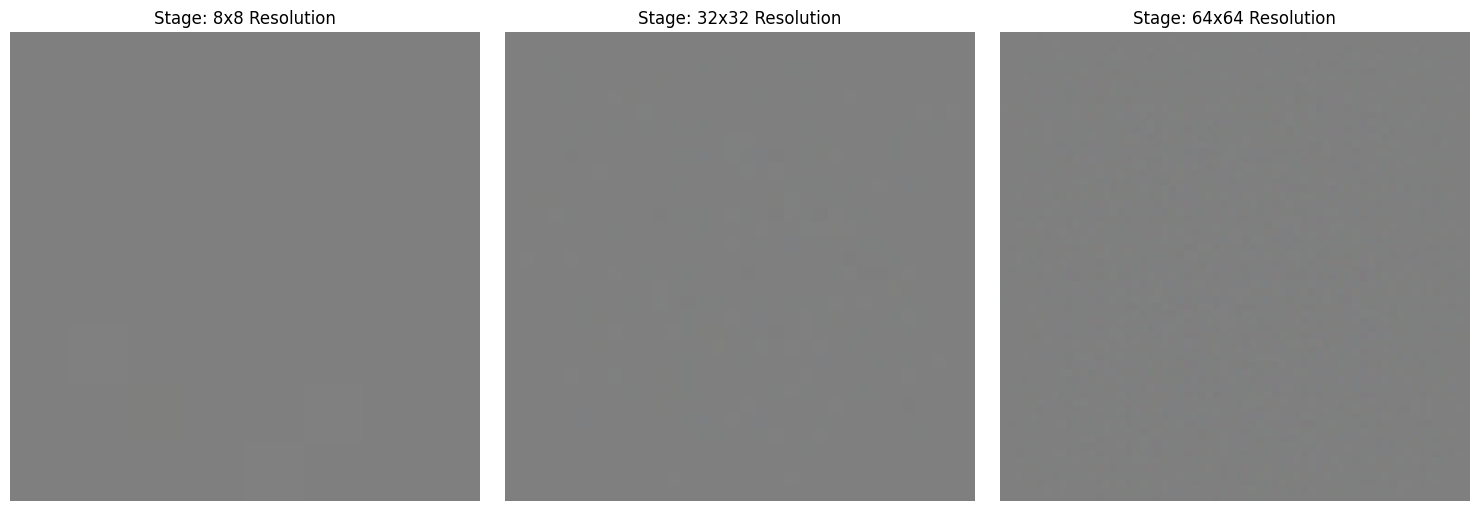

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup - We use CIFAR-10 (small animal/object images) for this demo
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]

# 2. Simple Generator that can produce 64x64 images
def build_simple_pro_generator():
    model = models.Sequential([
        # Start small
        layers.Dense(4*4*256, input_dim=100),
        layers.Reshape((4, 4, 256)),
        # Upsample to 8x8
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(0.2),
        # Upsample to 16x16
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(0.2),
        # Upsample to 32x32
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(0.2),
        # Upsample to 64x64
        layers.Conv2DTranspose(64, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(0.2),
        # Final Output Layer
        layers.Conv2D(3, (3,3), activation='tanh', padding='same')
    ])
    return model

# 3. Function to visualize the "Growth" process
def visualize_growth(gen, noise):
    img_64 = gen(noise, training=False)

    resolutions = [8, 32, 64]
    plt.figure(figsize=(15, 5))

    for i, res in enumerate(resolutions):
        plt.subplot(1, 3, i+1)
        # Resize the image to simulate the training stage
        low_res_img = tf.image.resize(img_64, [res, res])[0]
        # Rescale back to 0-1 for plotting
        plt.imshow((low_res_img + 1) / 2)
        plt.title(f"Stage: {res}x{res} Resolution")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the simulation
generator = build_simple_pro_generator()
random_noise = tf.random.normal([1, 100])
print("Simulating Progressive Growth from 8x8 to 64x64...")
visualize_growth(generator, random_noise)